In [138]:
import os
import datetime
import numpy as np
from modules.setting import OUTPUT_PATH

# データ読み込み
x_train = np.load(f"{OUTPUT_PATH}/x_train.npy")
x_val = np.load(f"{OUTPUT_PATH}/x_val.npy")
y_train = np.load(f"{OUTPUT_PATH}/y_train.npy")
y_val = np.load(f"{OUTPUT_PATH}/y_val.npy")

In [139]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers.convolutional import Conv2D
from keras.layers.pooling import MaxPooling2D, AveragePooling2D
from keras.layers.core import Dense, Activation, Dropout, Flatten

now = datetime.datetime.now()
RESULT_PATH = f"{OUTPUT_PATH}/results/{now:%m-%d_%H-%M-%S}"
os.makedirs(RESULT_PATH, exist_ok=True)
##############ネットワークを設計してください．##################
model = Sequential()

model.add(Conv2D(8, (3, 3), padding="valid", strides=1, input_shape=x_train.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Flatten())
model.add(Dense(4))
model.add(Activation("softmax"))
#########################################################

model.summary()

Model: "sequential_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 49, 49, 8)         80        
                                                                 
 activation_40 (Activation)  (None, 49, 49, 8)         0         
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 16, 16, 8)        0         
 g2D)                                                            
                                                                 
 flatten_20 (Flatten)        (None, 2048)              0         
                                                                 
 dense_20 (Dense)            (None, 4)                 8196      
                                                                 
 activation_41 (Activation)  (None, 4)                 0         
                                                     

In [140]:
from keras.callbacks import EarlyStopping

# コンパイル
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["acc"])

# Early stopping
early_stopping = EarlyStopping(monitor="val_loss", patience=5, verbose=1)

# 学習
history = model.fit(
    x_train,
    y_train,
    batch_size=16,
    epochs=100,
    validation_data=(x_val, y_val),
    verbose=1,
    callbacks=[early_stopping],
)

Epoch 1/100
64/64 [==============================] - 2s 24ms/step - loss: 1.3998 - acc: 0.2695 - val_loss: 1.3885 - val_acc: 0.2500
Epoch 2/100
64/64 [==============================] - 1s 18ms/step - loss: 1.3837 - acc: 0.2852 - val_loss: 1.3954 - val_acc: 0.2500
Epoch 3/100
64/64 [==============================] - 1s 17ms/step - loss: 1.3634 - acc: 0.3232 - val_loss: 1.3565 - val_acc: 0.2695
Epoch 4/100
64/64 [==============================] - 1s 15ms/step - loss: 1.3490 - acc: 0.3662 - val_loss: 1.3396 - val_acc: 0.3984
Epoch 5/100
64/64 [==============================] - 1s 13ms/step - loss: 1.3321 - acc: 0.4131 - val_loss: 1.3358 - val_acc: 0.2539
Epoch 6/100
64/64 [==============================] - 1s 19ms/step - loss: 1.3130 - acc: 0.4961 - val_loss: 1.3174 - val_acc: 0.2695
Epoch 7/100
64/64 [==============================] - 1s 20ms/step - loss: 1.2924 - acc: 0.5195 - val_loss: 1.2891 - val_acc: 0.5195
Epoch 8/100
64/64 [==============================] - 1s 20ms/step - loss: 1.

64/64 [==============================] - 1s 20ms/step - loss: 0.1558 - acc: 0.9697 - val_loss: 0.2470 - val_acc: 0.9258
Epoch 63/100
64/64 [==============================] - 1s 20ms/step - loss: 0.1544 - acc: 0.9600 - val_loss: 0.3072 - val_acc: 0.9023
Epoch 64/100
64/64 [==============================] - 1s 19ms/step - loss: 0.1430 - acc: 0.9736 - val_loss: 0.2472 - val_acc: 0.9375
Epoch 65/100
64/64 [==============================] - 1s 21ms/step - loss: 0.1535 - acc: 0.9678 - val_loss: 0.2581 - val_acc: 0.8984
Epoch 66/100
64/64 [==============================] - 1s 20ms/step - loss: 0.1472 - acc: 0.9697 - val_loss: 0.2393 - val_acc: 0.9180
Epoch 67/100
64/64 [==============================] - 1s 21ms/step - loss: 0.1387 - acc: 0.9775 - val_loss: 0.2347 - val_acc: 0.9219
Epoch 68/100
64/64 [==============================] - 1s 20ms/step - loss: 0.1422 - acc: 0.9668 - val_loss: 0.2360 - val_acc: 0.9180
Epoch 69/100
64/64 [==============================] - 1s 19ms/step - loss: 0.1381 

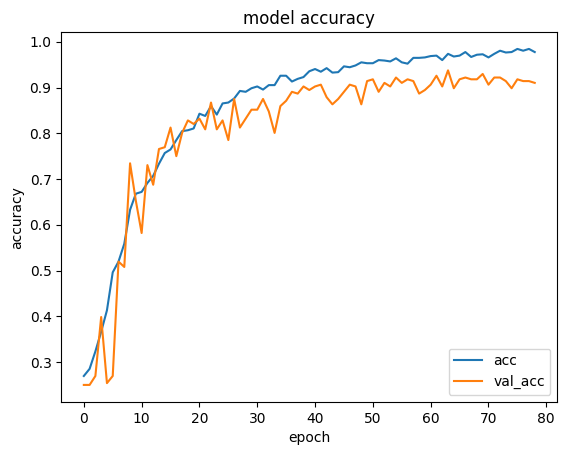

In [141]:
# エポックごとの訓練データの正答率とバリデーションデータの正答率
import matplotlib.pyplot as plt

plt.plot(history.history["acc"])
plt.plot(history.history["val_acc"])
plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(["acc", "val_acc"], loc="lower right")
plt.savefig(f"{RESULT_PATH}/accuracy.png")
plt.show()


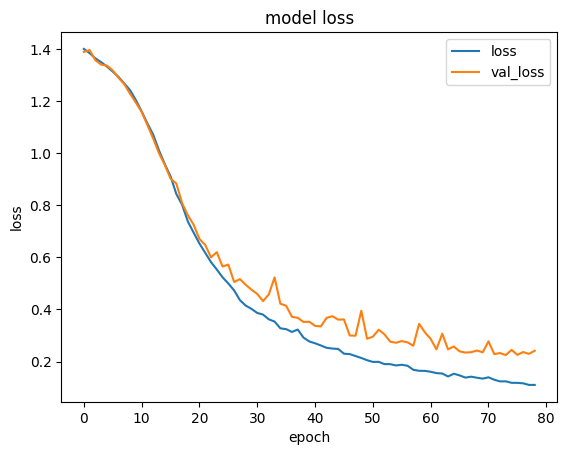

In [142]:
# エポックごとの訓練データの損失とバリデーションデータの損失
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["loss", "val_loss"], loc="upper right")
plt.savefig(f"{RESULT_PATH}/loss.png")
plt.show()

In [143]:
# モデルと重みの保存
save_model = model.to_json()
with open(f"{OUTPUT_PATH}/model.json", mode="w") as f:
    f.write(save_model)
model.save_weights(f"{OUTPUT_PATH}/weight.hdf5")